In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load saved data
df_combined = pd.read_csv("../models/df_combined.csv")
df_disagree = pd.read_csv("../models/df_disagree.csv")
df_missed = pd.read_csv("../models/df_missed.csv")

os.makedirs("../models/charts", exist_ok=True)

print("Data loaded:")
print(f"  df_combined: {df_combined.shape}")
print(f"  df_disagree: {df_disagree.shape}")
print(f"  df_missed:   {df_missed.shape}")

Data loaded:
  df_combined: (200, 11)
  df_disagree: (97, 11)
  df_missed:   (15, 11)


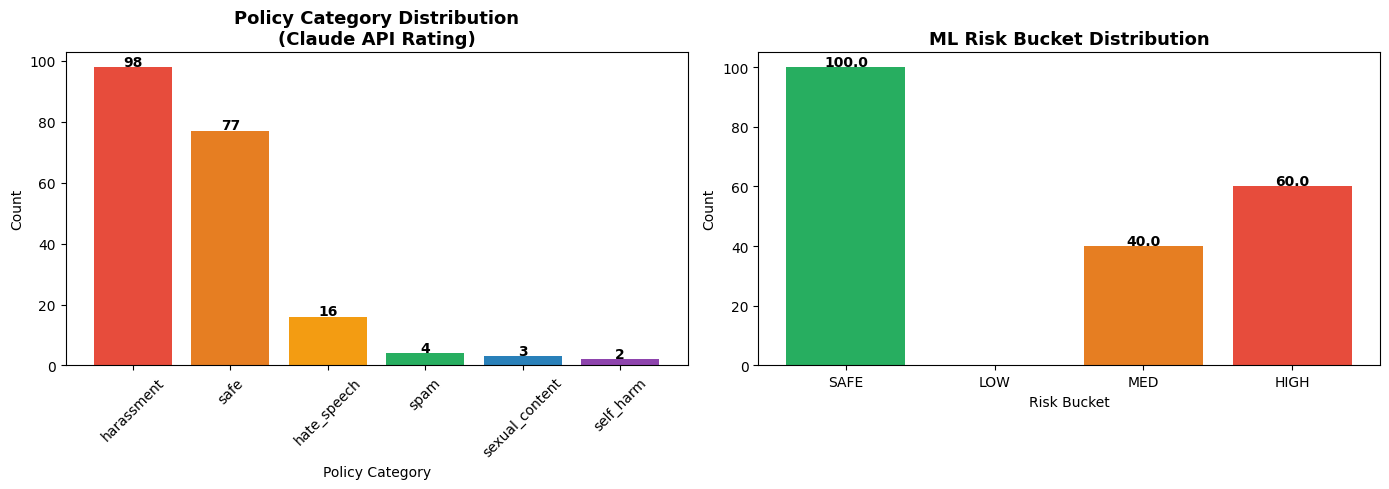

Chart saved ✓


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — Claude policy category distribution
category_counts = df_combined["claude_category"].value_counts()
colors = ["#e74c3c", "#e67e22", "#f39c12", "#27ae60", "#2980b9", "#8e44ad", "#95a5a6"]
axes[0].bar(category_counts.index, category_counts.values, color=colors[:len(category_counts)])
axes[0].set_title("Policy Category Distribution\n(Claude API Rating)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Policy Category")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)
for i, v in enumerate(category_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha="center", fontweight="bold")

# Right — ML risk bucket distribution
bucket_order = ["SAFE", "LOW", "MED", "HIGH"]
bucket_counts = df_combined["ml_bucket"].value_counts().reindex(bucket_order)
bucket_colors = ["#27ae60", "#f39c12", "#e67e22", "#e74c3c"]
axes[1].bar(bucket_order, bucket_counts.values, color=bucket_colors)
axes[1].set_title("ML Risk Bucket Distribution", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Risk Bucket")
axes[1].set_ylabel("Count")
for i, v in enumerate(bucket_counts.values):
    axes[1].text(i, v + 0.5, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../models/charts/distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved ✓")

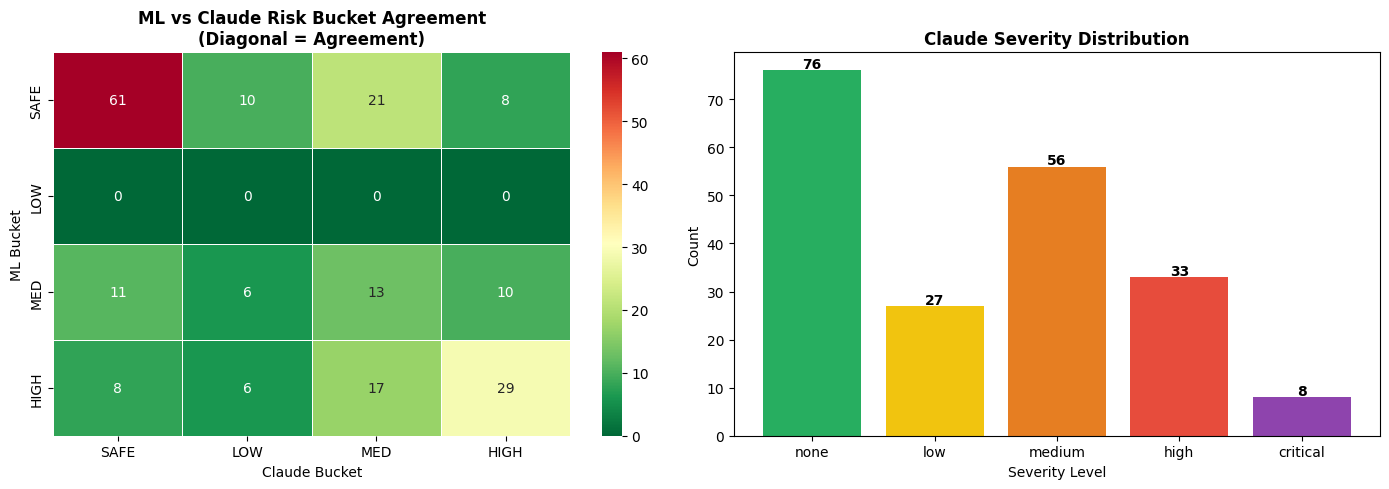

Chart saved ✓


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — Confusion heatmap ML vs Claude buckets
bucket_order = ["SAFE", "LOW", "MED", "HIGH"]
crosstab = pd.crosstab(
    df_combined["ml_bucket"], 
    df_combined["claude_bucket"]
).reindex(index=bucket_order, columns=bucket_order, fill_value=0)

sns.heatmap(
    crosstab, 
    annot=True, 
    fmt="d", 
    cmap="RdYlGn_r",
    ax=axes[0],
    linewidths=0.5
)
axes[0].set_title("ML vs Claude Risk Bucket Agreement\n(Diagonal = Agreement)", 
                   fontsize=12, fontweight="bold")
axes[0].set_xlabel("Claude Bucket")
axes[0].set_ylabel("ML Bucket")

# Right — Severity distribution from Claude
severity_order = ["none", "low", "medium", "high", "critical"]
severity_counts = df_combined["claude_severity"].value_counts().reindex(severity_order, fill_value=0)
severity_colors = ["#27ae60", "#f1c40f", "#e67e22", "#e74c3c", "#8e44ad"]
axes[1].bar(severity_order, severity_counts.values, color=severity_colors)
axes[1].set_title("Claude Severity Distribution", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Severity Level")
axes[1].set_ylabel("Count")
for i, v in enumerate(severity_counts.values):
    axes[1].text(i, v + 0.5, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../models/charts/disagreement.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved ✓")

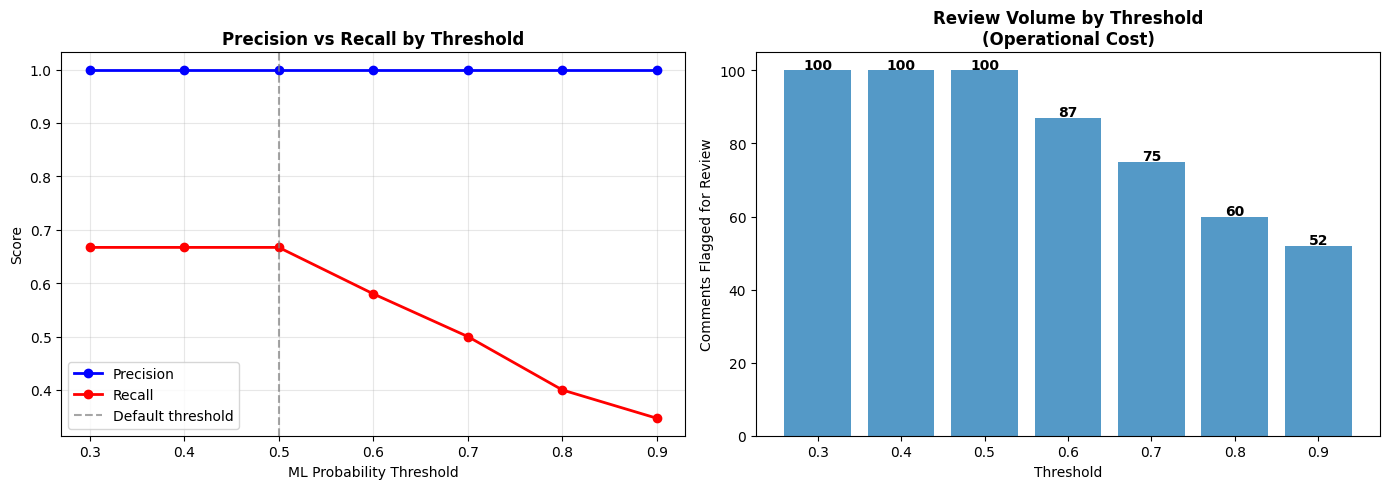

Threshold tuning table:
 threshold  precision  recall  review_volume
       0.3        1.0   0.667            100
       0.4        1.0   0.667            100
       0.5        1.0   0.667            100
       0.6        1.0   0.580             87
       0.7        1.0   0.500             75
       0.8        1.0   0.400             60
       0.9        1.0   0.347             52


In [4]:
# Simulate threshold tuning on the 200 sample
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
results_thresh = []

for t in thresholds:
    ml_pred = (df_combined["ml_prob"] >= t).astype(int)
    true = df_combined["true_label"]
    
    tp = ((ml_pred == 1) & (true == 1)).sum()
    fp = ((ml_pred == 1) & (true == 0)).sum()
    fn = ((ml_pred == 0) & (true == 1)).sum()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    review_volume = ml_pred.sum()
    
    results_thresh.append({
        "threshold": t,
        "precision": round(precision, 3),
        "recall": round(recall, 3),
        "review_volume": review_volume
    })

df_thresh = pd.DataFrame(results_thresh)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — Precision vs Recall
axes[0].plot(df_thresh["threshold"], df_thresh["precision"], 
             "b-o", label="Precision", linewidth=2)
axes[0].plot(df_thresh["threshold"], df_thresh["recall"], 
             "r-o", label="Recall", linewidth=2)
axes[0].axvline(x=0.5, color="gray", linestyle="--", alpha=0.7, label="Default threshold")
axes[0].set_title("Precision vs Recall by Threshold", fontsize=12, fontweight="bold")
axes[0].set_xlabel("ML Probability Threshold")
axes[0].set_ylabel("Score")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right — Review volume by threshold
axes[1].bar(df_thresh["threshold"].astype(str), df_thresh["review_volume"], 
            color="#2980b9", alpha=0.8)
axes[1].set_title("Review Volume by Threshold\n(Operational Cost)", 
                   fontsize=12, fontweight="bold")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Comments Flagged for Review")
for i, v in enumerate(df_thresh["review_volume"]):
    axes[1].text(i, v + 0.5, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../models/charts/threshold_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

print("Threshold tuning table:")
print(df_thresh.to_string(index=False))

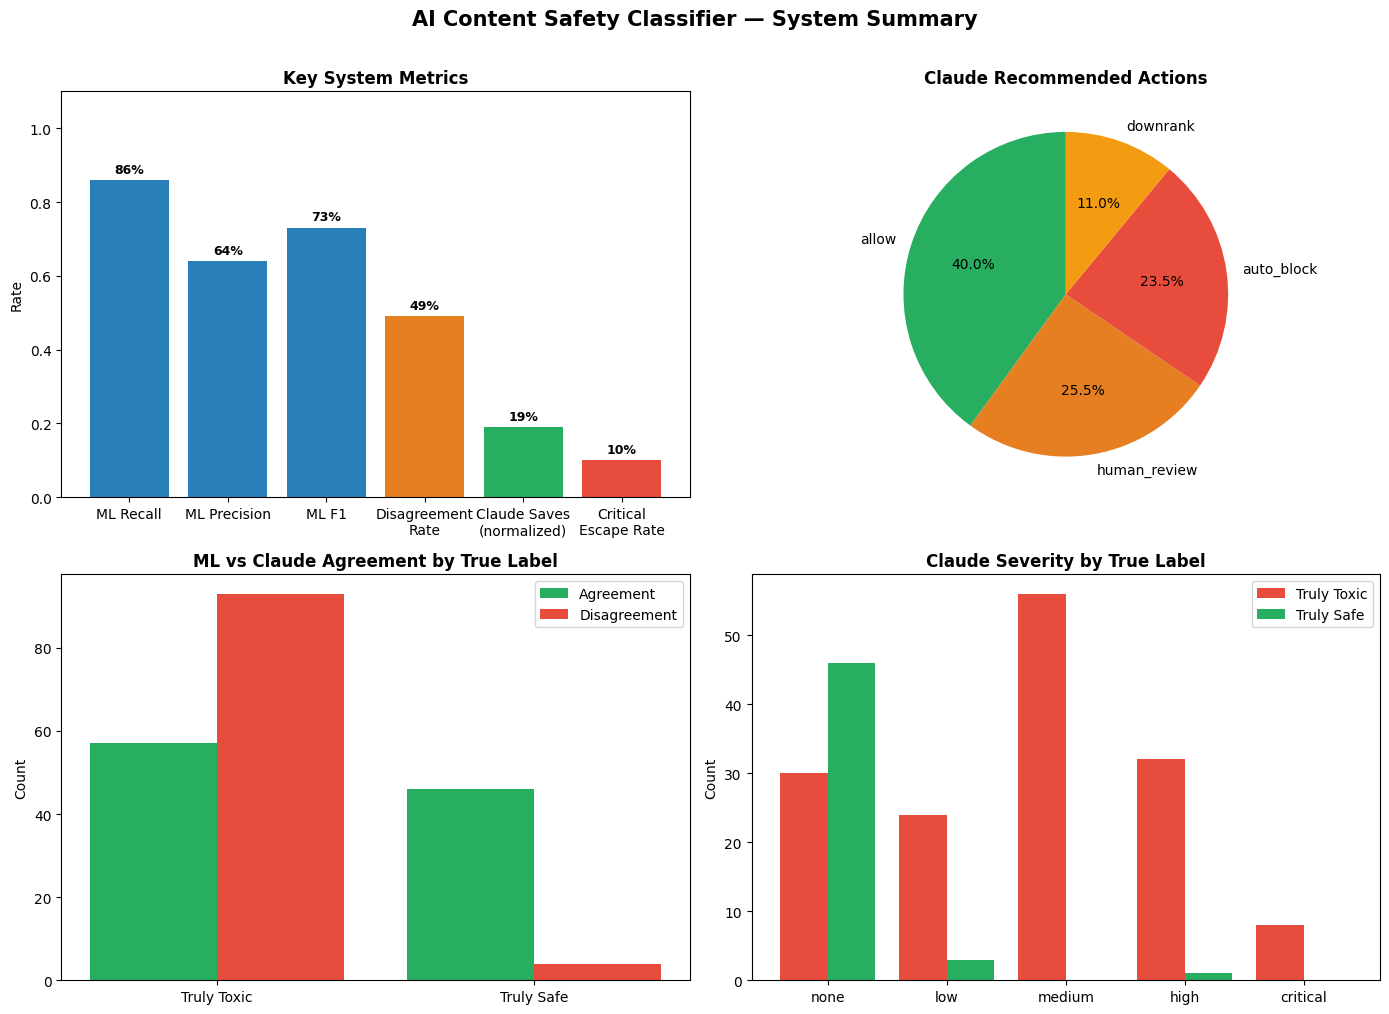

Summary chart saved ✓


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("AI Content Safety Classifier — System Summary", 
             fontsize=15, fontweight="bold", y=1.01)

# Top left — Key metrics
metrics = {
    "ML Recall": 0.86,
    "ML Precision": 0.64,
    "ML F1": 0.73,
    "Disagreement\nRate": 0.49,
    "Claude Saves\n(normalized)": round(28/150, 2),
    "Critical\nEscape Rate": 0.10
}
colors_m = ["#2980b9", "#2980b9", "#2980b9", "#e67e22", "#27ae60", "#e74c3c"]
axes[0,0].bar(metrics.keys(), metrics.values(), color=colors_m)
axes[0,0].set_title("Key System Metrics", fontweight="bold")
axes[0,0].set_ylabel("Rate")
axes[0,0].set_ylim(0, 1.1)
for i, (k, v) in enumerate(metrics.items()):
    axes[0,0].text(i, v + 0.02, f"{v:.0%}", ha="center", fontsize=9, fontweight="bold")

# Top right — Action distribution
action_counts = df_combined["claude_action"].value_counts()
action_colors = {"auto_block": "#e74c3c", "human_review": "#e67e22", 
                 "downrank": "#f39c12", "allow": "#27ae60"}
colors_a = [action_colors.get(a, "#95a5a6") for a in action_counts.index]
axes[0,1].pie(action_counts.values, labels=action_counts.index, 
              colors=colors_a, autopct="%1.1f%%", startangle=90)
axes[0,1].set_title("Claude Recommended Actions", fontweight="bold")

# Bottom left — Agreement vs disagreement by true label
agree_toxic = len(df_combined[(df_combined["disagree"]==False) & (df_combined["true_label"]==1)])
agree_safe = len(df_combined[(df_combined["disagree"]==False) & (df_combined["true_label"]==0)])
disagree_toxic = len(df_combined[(df_combined["disagree"]==True) & (df_combined["true_label"]==1)])
disagree_safe = len(df_combined[(df_combined["disagree"]==True) & (df_combined["true_label"]==0)])

x = np.arange(2)
axes[1,0].bar(x - 0.2, [agree_toxic, agree_safe], 0.4, label="Agreement", color="#27ae60")
axes[1,0].bar(x + 0.2, [disagree_toxic, disagree_safe], 0.4, label="Disagreement", color="#e74c3c")
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(["Truly Toxic", "Truly Safe"])
axes[1,0].set_title("ML vs Claude Agreement by True Label", fontweight="bold")
axes[1,0].set_ylabel("Count")
axes[1,0].legend()

# Bottom right — Claude severity by true label
sev_order = ["none", "low", "medium", "high", "critical"]
toxic_sev = df_combined[df_combined["true_label"]==1]["claude_severity"].value_counts().reindex(sev_order, fill_value=0)
safe_sev = df_combined[df_combined["true_label"]==0]["claude_severity"].value_counts().reindex(sev_order, fill_value=0)

x = np.arange(len(sev_order))
axes[1,1].bar(x - 0.2, toxic_sev.values, 0.4, label="Truly Toxic", color="#e74c3c")
axes[1,1].bar(x + 0.2, safe_sev.values, 0.4, label="Truly Safe", color="#27ae60")
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(sev_order)
axes[1,1].set_title("Claude Severity by True Label", fontweight="bold")
axes[1,1].set_ylabel("Count")
axes[1,1].legend()

plt.tight_layout()
plt.savefig("../models/charts/summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Summary chart saved ✓")